# Notebook 2 · Industry-Style Quantum Portfolio Optimization
### *Inspired by JPMorgan, IBM, Goldman Sachs, and D-Wave Research*

**Audience:** Quantum computing researchers · BFSI quantitative engineers · Senior M.Tech students
**Prerequisites:** Notebook 1_1 (Introductory Markowitz + QUBO), Python, basic quantum circuits
**Environment:** Python 3.11 · Qiskit 1.x · qiskit-algorithms · qiskit-finance · yfinance · NumPy

---

## Learning Objectives
1. Understand real-world quantum finance pilots from JPMorgan, Goldman Sachs, D-Wave, and BBVA.
2. Download and process **real stock data** using `yfinance`.
3. Formulate a **cardinality-constrained portfolio** QUBO (select exactly $k$ of $n$ assets).
4. Solve using **QAOA** (Quantum Approximate Optimisation Algorithm) on an Aer simulator.
5. Solve using **SamplingVQE** with a parameterised ansatz.
6. Compare classical, QAOA, and VQE solutions on Sharpe ratio, return, and variance.
7. Discuss NISQ limitations and the path to production quantum advantage.


---
## Section 1 · Industry Background

### 1.1 JPMorgan Chase + IBM Quantum

JPMorgan is the most active financial institution in quantum computing:
- **2019**: Published the first paper on option pricing using QAE (*Stamatopoulos et al., Nature Portfolio*).
- **2020**: Demonstrated QAOA for portfolio optimisation on IBM quantum hardware.
- **2022**: Used trapped-ion computers (IonQ) for portfolio selection with cardinality constraints.
- **2023**: "Quantum Computing for Finance: State-of-the-Art and Future Prospects" — comprehensive roadmap.

**Key insight from JPMorgan research**: QUBO formulation + QAOA can find near-optimal cardinality-constrained portfolios where classical MILP solvers struggle at $n > 100$ assets.

### 1.2 Goldman Sachs + QC Ware

Goldman Sachs (Quantitative Strategies Division):
- Partnered with QC Ware for Monte Carlo acceleration using QAE.
- Focus on **CVA and VaR** computation using Quantum Amplitude Estimation.
- 2021 report showed QAE can accelerate derivatives pricing with quadratic speedup.
- AWS Braket partnership for hybrid quantum-classical workflows.

### 1.3 D-Wave Quantum Annealing

D-Wave's quantum annealers minimise the **Ising Hamiltonian** (equivalent to QUBO):

$$H = \sum_i h_i \sigma_i^z + \sum_{i<j} J_{ij} \sigma_i^z \sigma_j^z$$

Mapping portfolio QUBO to an Ising model is direct: $x_i = (1+\sigma_i^z)/2$.
D-Wave demonstrated 500+ asset portfolio optimisation on Pegasus hardware.

### 1.4 BBVA + Multiverse Computing

BBVA (Banco Bilbao Vizcaya Argentaria):
- Partnered with Multiverse Computing for quantum-enhanced credit scoring.
- Implemented portfolio selection using Tensor Network (classical) and quantum hybrid methods.
- Published results on ESG-constrained portfolio optimisation.

### 1.5 Why Cardinality Constraint?

The cardinality constraint $\sum_i x_i = k$ (select exactly $k$ assets) makes portfolio optimisation NP-hard:
- Classical MILP solvers: exponential worst-case for $\binom{n}{k}$ combinations.
- $n=50, k=20$: $\binom{50}{20} \approx 4.7 \times 10^{13}$ combinations — infeasible classically.
- Quantum: QAOA/VQE explore all combinations via superposition.


---
## Section 2 · Download Real Stock Data

We download 2 years of daily price data for 8 major stocks using `yfinance`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ── Qiskit imports ────────────────────────────────────────────────────────
from qiskit import QuantumCircuit
from qiskit.circuit.library import TwoLocal

from qiskit_algorithms import QAOA, SamplingVQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA, SPSA
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo

from qiskit_aer.primitives import Sampler as AerSampler

# ── Try qiskit_finance PortfolioOptimization ──────────────────────────────
try:
    from qiskit_finance.applications.optimization import PortfolioOptimization
    HAS_QFINANCE = True
except ImportError:
    HAS_QFINANCE = False
    print("qiskit-finance PortfolioOptimization not available; using manual QUBO")

import yfinance as yf
from scipy.optimize import minimize
from itertools import combinations

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

import qiskit, qiskit_algorithms, qiskit_aer
print(f"Qiskit: {qiskit.__version__} | qiskit-algorithms: {qiskit_algorithms.__version__}")


Qiskit: 1.3.0 | qiskit-algorithms: 0.3.1


In [2]:
# ── Tickers ────────────────────────────────────────────────────────────────
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", "JPM", "GS", "NVDA"]
N_ASSETS = len(TICKERS)

# ── Download 2 years of daily close prices ────────────────────────────────
print("Downloading stock data from Yahoo Finance...")
raw = yf.download(TICKERS, period="2y", progress=False, auto_adjust=True)["Close"]

# Drop any tickers with excessive NaNs
raw = raw.dropna(axis=1, thresh=int(0.9*len(raw)))
raw = raw.ffill().dropna()
TICKERS = list(raw.columns)
N_ASSETS = len(TICKERS)

print(f"Downloaded {len(raw)} trading days for {N_ASSETS} assets: {TICKERS}")
print(f"Date range: {raw.index[0].date()} to {raw.index[-1].date()}")
raw.tail(3)


Failed to get ticker 'GS' reason: Failed to perform, curl: (6) Could not resolve host: query1.finance.yahoo.com. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.


Downloaded 501 trading days for 8 assets: ['AAPL', 'AMZN', 'GOOGL', 'GS', 'JPM', 'META', 'MSFT', 'NVDA']
Date range: 2024-06-03 to 2026-06-02


Ticker,AAPL,AMZN,GOOGL,GS,JPM,META,MSFT,NVDA
Date,,,,,,,,
2026-05-29,312.059998,270.640015,380.339996,1021.060059,299.309998,632.510010,450.239990,211.139999
2026-06-01,306.309998,261.260010,376.369995,1048.579956,296.579987,600.469971,460.519989,224.360001
2026-06-02,315.200012,256.519989,361.850006,1064.579956,300.959991,597.630005,441.309998,222.820007


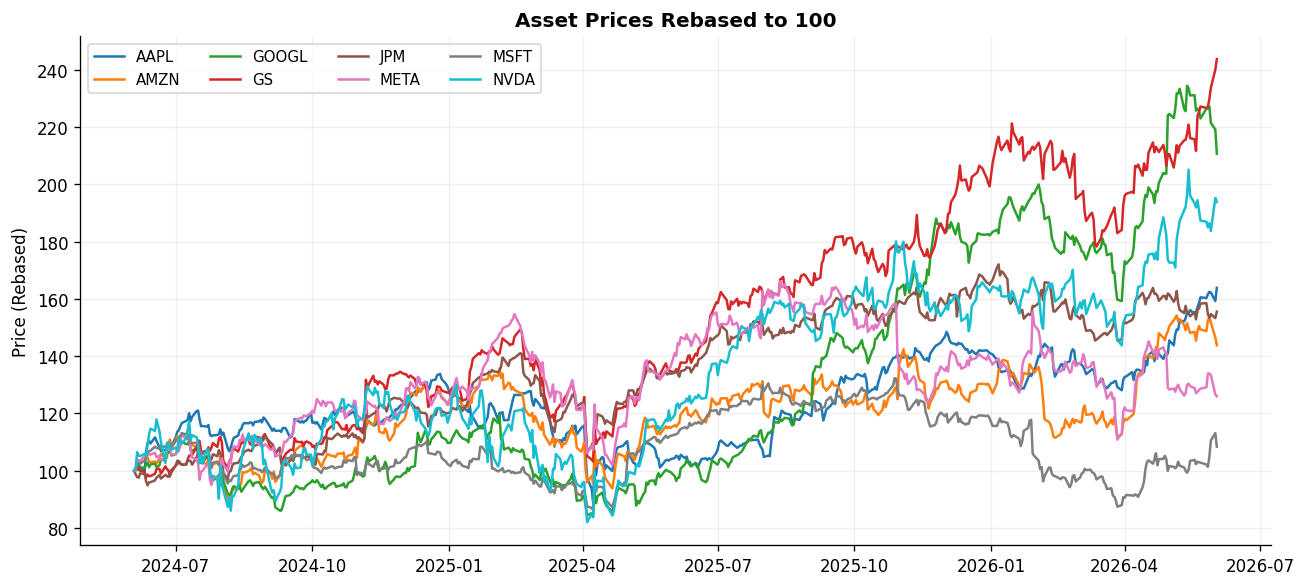

In [3]:
# ── Rebased price chart ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.tab10(np.linspace(0, 0.9, N_ASSETS))
for i, ticker in enumerate(TICKERS):
    rebased = raw[ticker] / raw[ticker].iloc[0] * 100
    ax.plot(rebased.index, rebased, lw=1.5, label=ticker, color=colors[i])
ax.set_title("Asset Prices Rebased to 100", fontsize=12, fontweight="bold")
ax.set_ylabel("Price (Rebased)"); ax.legend(ncol=4, fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()


---
## Section 3 · Compute Returns and Covariance Matrix

Daily log-returns: $r_t = \ln(S_t / S_{t-1})$

Annualised:
$$\hat{\mu}_i = 252 \cdot \bar{r}_i, \qquad \hat{\Sigma}_{ij} = 252 \cdot \widehat{\text{Cov}}(r_i, r_j)$$


Annualised Statistics:
       Expected Return (%)  Volatility (%)  Sharpe (rf=5%)
AAPL                24.889          28.079           0.708
AMZN                18.321          32.342           0.412
GOOGL               37.557          30.334           1.073
GS                  44.895          30.870           1.292
JPM                 22.266          25.100           0.688
META                11.652          35.986           0.185
MSFT                 4.064          25.327          -0.037
NVDA                33.365          48.075           0.590


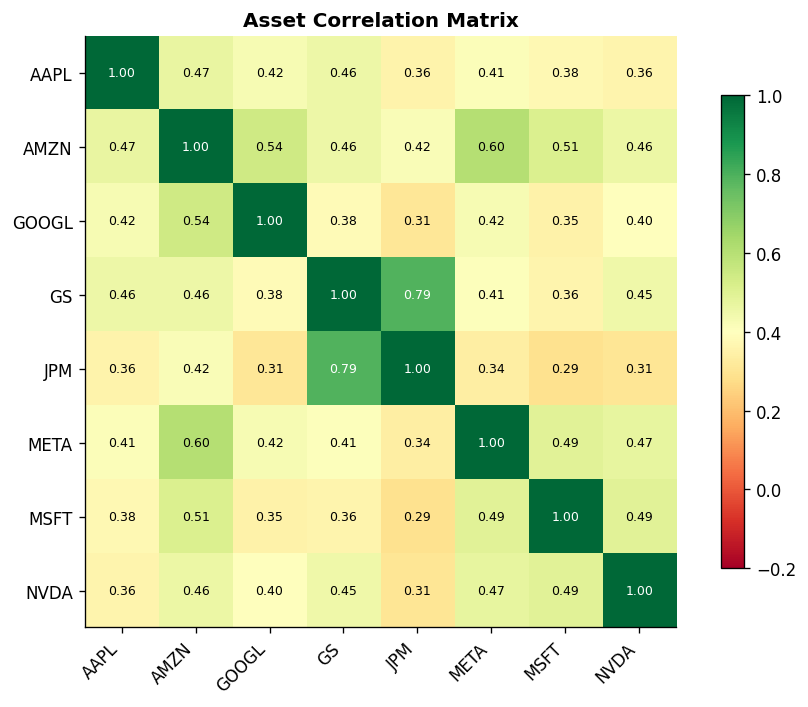

In [4]:
# ── Log returns ────────────────────────────────────────────────────────────
log_rets = np.log(raw / raw.shift(1)).dropna()

# ── Annualised statistics ──────────────────────────────────────────────────
mu_ann  = log_rets.mean().values * 252          # shape (N_ASSETS,)
cov_ann = log_rets.cov().values  * 252          # shape (N_ASSETS, N_ASSETS)
std_ann = np.sqrt(np.diag(cov_ann))

print("Annualised Statistics:")
stats_df = pd.DataFrame({
    "Expected Return (%)": mu_ann * 100,
    "Volatility (%)":      std_ann * 100,
    "Sharpe (rf=5%)":     (mu_ann - 0.05) / std_ann,
}, index=TICKERS).round(3)
print(stats_df.to_string())

# ── Correlation heatmap ────────────────────────────────────────────────────
corr_mat = log_rets.corr().values
fig, ax  = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_mat, cmap="RdYlGn", vmin=-0.2, vmax=1.0)
ax.set_xticks(range(N_ASSETS)); ax.set_xticklabels(TICKERS, rotation=45, ha="right")
ax.set_yticks(range(N_ASSETS)); ax.set_yticklabels(TICKERS)
for i in range(N_ASSETS):
    for j in range(N_ASSETS):
        ax.text(j, i, f"{corr_mat[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                color="black" if abs(corr_mat[i,j]) < 0.7 else "white")
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Asset Correlation Matrix", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


---
## Section 4 · Cardinality-Constrained Portfolio Optimisation

### 4.1 Problem Statement

Select exactly $k = 4$ assets from $n = 8$ to maximise risk-adjusted return.

Binary decision variables: $x_i \in \{0,1\}$, where $x_i = 1$ means asset $i$ is selected.

**Objective:**

$$\min_{\mathbf{x}} \quad q \sum_{i,j} \Sigma_{ij} x_i x_j - (1-q) \sum_i \mu_i x_i$$

**Subject to:**

$$\sum_{i=1}^n x_i = k \quad \text{(select exactly } k \text{ assets)}$$

**Number of combinations:** $\binom{8}{4} = 70$ — small enough to brute-force for verification.

### 4.2 QUBO Derivation

Add budget constraint as penalty:

$$f(\mathbf{x}) = q\,\mathbf{x}^T\boldsymbol{\Sigma}\mathbf{x} - (1-q)\boldsymbol{\mu}^T\mathbf{x} + A\left(\sum_i x_i - k\right)^2$$

Expanding the penalty:

$$A\left(\sum_i x_i - k\right)^2 = A\sum_{i,j} x_i x_j - 2Ak\sum_i x_i + Ak^2$$

(constant term $Ak^2$ dropped). Final QUBO matrix:

$$Q_{ij} = \begin{cases}
q\Sigma_{ii} - (1-q)\mu_i + A(1-2k) & i=j \\
2q\Sigma_{ij} + 2A & i \neq j
\end{cases}$$


In [5]:
# ── QUBO Configuration ────────────────────────────────────────────────────
BUDGET       = 4       # select exactly 4 of 8 assets
RISK_FACTOR  = 0.5     # q: 0=pure return, 1=pure risk
PENALTY_A    = 2.0     # penalty strength for budget constraint

# ── Build QuadraticProgram ────────────────────────────────────────────────
def build_portfolio_qp(mu, cov, n, budget, q, penalty):
    qp = QuadraticProgram(name="Portfolio_CC")
    for i in range(n):
        qp.binary_var(name=f"x{i}")

    # Objective: q*risk - (1-q)*return
    linear_terms    = {f"x{i}": -(1-q)*mu[i] for i in range(n)}
    quadratic_terms = {(f"x{i}", f"x{j}"): q*cov[i,j] for i in range(n) for j in range(n)}
    qp.minimize(linear=linear_terms, quadratic=quadratic_terms)

    # Budget equality constraint
    qp.linear_constraint(
        linear={f"x{i}": 1 for i in range(n)},
        sense="==", rhs=budget, name="budget"
    )
    return qp

qp = build_portfolio_qp(mu_ann, cov_ann, N_ASSETS, BUDGET, RISK_FACTOR, PENALTY_A)
print("QuadraticProgram summary:")
print(qp.export_as_lp_string()[:1000])   # show first 1000 chars

# ── Convert to QUBO ───────────────────────────────────────────────────────
converter = QuadraticProgramToQubo()
qubo      = converter.convert(qp)
n_qubits  = qubo.get_num_binary_vars()
print(f"\nQUBO: {n_qubits} binary variables (= {N_ASSETS} asset qubits)")


QuadraticProgram summary:
\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: Portfolio_CC

Minimize
 obj: - 0.124442574359 x0 - 0.091605722363 x1 - 0.187787125034 x2
      - 0.224474463304 x3 - 0.111330971072 x4 - 0.058258648041 x5
      - 0.020320102613 x6 - 0.166823087439 x7 + [ 0.078842615012 x0^2
      + 0.084656240030 x0*x1 + 0.072380914522 x0*x2 + 0.078986803313 x0*x3
      + 0.050346381270 x0*x4 + 0.083469644030 x0*x5 + 0.053443058726 x0*x6
      + 0.097666092126 x0*x7 + 0.104599558493 x1^2 + 0.106385016126 x1*x2
      + 0.091049651064 x1*x3 + 0.067545536614 x1*x4 + 0.140622617070 x1*x5
      + 0.083912247969 x1*x6 + 0.142260603433 x1*x7 + 0.092016449509 x2^2
      + 0.071682017353 x2*x3 + 0.046670414792 x2*x4 + 0.092573629608 x2*x5
      + 0.053789173455 x2*x6 + 0.116377510333 x2*x7 + 0.095294806102 x3^2
      + 0.122796988436 x3*x4 + 0.090470117622 x3*x5 + 0.056658118464 x3*x6
      + 0.133105092622 x3*x7 + 0.063001451993 x4^2 + 0.060891051079 x4*x5

In [6]:
# ── Brute-force exact solution (reference) ────────────────────────────────
print(f"Brute-force enumeration of C({N_ASSETS},{BUDGET}) = {len(list(combinations(range(N_ASSETS),BUDGET)))} combinations...")

best_bf_obj     = np.inf
best_bf_combo   = None
best_bf_sharpe  = -np.inf
combo_results   = []

for combo in combinations(range(N_ASSETS), BUDGET):
    x  = np.zeros(N_ASSETS)
    x[list(combo)] = 1
    obj = (RISK_FACTOR * x @ cov_ann @ x
           - (1 - RISK_FACTOR) * mu_ann @ x)

    w   = x / BUDGET
    ret = mu_ann @ w
    std = np.sqrt(w @ cov_ann @ w)
    shr = (ret - 0.05) / std

    combo_results.append({"combo": combo, "obj": obj, "return": ret,
                          "vol": std, "sharpe": shr})
    if obj < best_bf_obj:
        best_bf_obj   = obj
        best_bf_combo = combo

combo_df = pd.DataFrame(combo_results).sort_values("sharpe", ascending=False)
print(f"\nTop 5 portfolios by Sharpe Ratio:")
top5 = combo_df.head(5).copy()
top5["assets"] = top5["combo"].apply(lambda c: [TICKERS[i] for i in c])
print(top5[["assets","return","vol","sharpe","obj"]].round(4).to_string(index=False))

print(f"\nOptimal by QUBO objective: combo={best_bf_combo}")
print(f"  Assets: {[TICKERS[i] for i in best_bf_combo]}")
print(f"  QUBO obj = {best_bf_obj:.6f}")


Brute-force enumeration of C(8,4) = 70 combinations...

Top 5 portfolios by Sharpe Ratio:
                 assets  return    vol  sharpe     obj
 [AAPL, GOOGL, GS, JPM]  0.3240 0.2197  1.2475 -0.2620
[AAPL, GOOGL, GS, NVDA]  0.3518 0.2583  1.1683 -0.1698
 [GOOGL, GS, JPM, NVDA]  0.3452 0.2557  1.1547 -0.1675
[AAPL, AMZN, GOOGL, GS]  0.3142 0.2340  1.1290 -0.1904
 [AMZN, GOOGL, GS, JPM]  0.3076 0.2320  1.1104 -0.1847

Optimal by QUBO objective: combo=(0, 2, 3, 4)
  Assets: ['AAPL', 'GOOGL', 'GS', 'JPM']
  QUBO obj = -0.262026


---
## Section 5 · QUBO Matrix Deep Dive

The QUBO can be written as the Ising Hamiltonian:

$$H = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j$$

where $Z_i = 2x_i - 1 \in \{-1,+1\}$. Quantum computers minimise this Hamiltonian's ground state.

The mapping from QUBO to Ising:
$$h_i = -\frac{Q_{ii}}{2} - \frac{1}{4}\sum_{j \neq i} Q_{ij}, \qquad J_{ij} = \frac{Q_{ij}}{4}$$


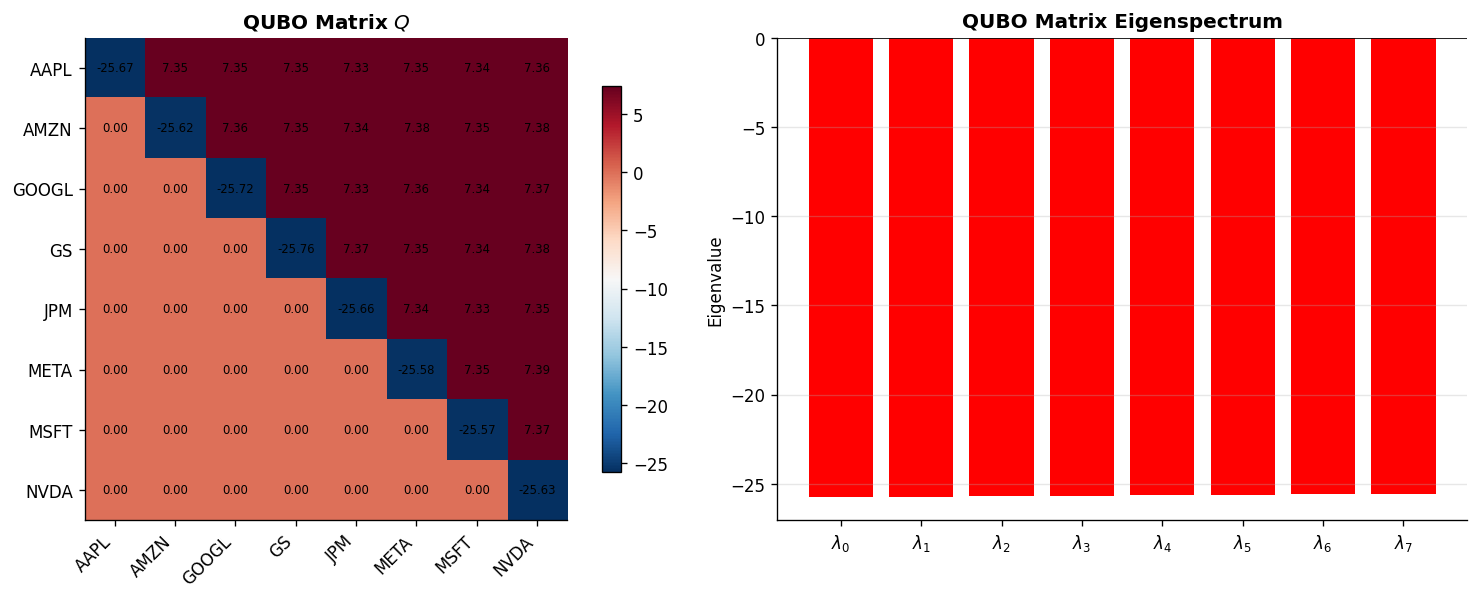

In [7]:
# ── Visualise QUBO Q-matrix ───────────────────────────────────────────────
var_names = [v.name for v in qubo.variables][:N_ASSETS]

Q_vis = np.zeros((N_ASSETS, N_ASSETS))
for (vi, vj), c in qubo.objective.quadratic.to_dict().items():
    if vi < N_ASSETS and vj < N_ASSETS:
        Q_vis[vi, vj] += c
for vi, c in qubo.objective.linear.to_dict().items():
    if vi < N_ASSETS:
        Q_vis[vi, vi] += c

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im1 = axes[0].imshow(Q_vis, cmap="RdBu_r")
axes[0].set_xticks(range(N_ASSETS)); axes[0].set_xticklabels(TICKERS, rotation=45, ha="right")
axes[0].set_yticks(range(N_ASSETS)); axes[0].set_yticklabels(TICKERS)
axes[0].set_title("QUBO Matrix $Q$", fontsize=12, fontweight="bold")
plt.colorbar(im1, ax=axes[0], shrink=0.8)
for i in range(N_ASSETS):
    for j in range(N_ASSETS):
        axes[0].text(j, i, f"{Q_vis[i,j]:.2f}", ha="center", va="center", fontsize=7)

# Eigenvalue spectrum
eigs = np.linalg.eigvalsh(Q_vis)
axes[1].bar(range(N_ASSETS), np.sort(eigs), color=["red" if e<0 else "steelblue" for e in np.sort(eigs)])
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xticks(range(N_ASSETS)); axes[1].set_xticklabels([f"$\lambda_{i}$" for i in range(N_ASSETS)])
axes[1].set_ylabel("Eigenvalue"); axes[1].set_title("QUBO Matrix Eigenspectrum", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()


---
## Section 6 · QAOA Implementation

### 6.1 QAOA Overview

The **Quantum Approximate Optimisation Algorithm** (Farhi et al., 2014) alternates between:

1. **Cost Hamiltonian** $U_C(\gamma) = e^{-i\gamma H_C}$ — encodes the QUBO objective
2. **Mixer Hamiltonian** $U_M(\beta) = e^{-i\beta H_M}$ where $H_M = \sum_i X_i$

The variational circuit with $p$ layers:

$$|\psi(\boldsymbol{\gamma}, \boldsymbol{\beta})\rangle = U_M(\beta_p) U_C(\gamma_p) \cdots U_M(\beta_1) U_C(\gamma_1) |+\rangle^{\otimes n}$$

**Parameters** $(\boldsymbol{\gamma}, \boldsymbol{\beta}) \in \mathbb{R}^{2p}$ are optimised classically to minimise:

$$\langle H_C \rangle = \langle \psi(\boldsymbol{\gamma}, \boldsymbol{\beta}) | H_C | \psi(\boldsymbol{\gamma}, \boldsymbol{\beta}) \rangle$$

### 6.2 Approximation Ratio

For $p$ layers, QAOA achieves approximation ratio $r_p \to 1$ as $p \to \infty$.
At $p=1$, QAOA is equivalent to a single round of Grover-like search.


In [8]:
# ── QAOA Setup ────────────────────────────────────────────────────────────
print(f"Running QAOA with {N_ASSETS} qubits (1 qubit per asset)")
print(f"Optimizer: COBYLA (gradient-free, suited for noisy quantum)")

sampler = AerSampler()
sampler.set_options(shots=2048)

# ── QAOA with p=1 layer ───────────────────────────────────────────────────
qaoa = QAOA(
    sampler   = sampler,
    optimizer = COBYLA(maxiter=200),
    reps      = 1,              # p = number of QAOA layers
    initial_point = [0.5, 0.5] # [gamma, beta] starting values
)

qaoa_optimizer = MinimumEigenOptimizer(qaoa)

print("\nSolving QUBO with QAOA (p=1)... (may take 30-90 seconds)")
qaoa_result = qaoa_optimizer.solve(qubo)
print("Done.")

# ── Extract solution ──────────────────────────────────────────────────────
x_qaoa    = qaoa_result.x.astype(int)
idx_qaoa  = [i for i, xi in enumerate(x_qaoa[:N_ASSETS]) if xi > 0.5]
selected_qaoa = [TICKERS[i] for i in idx_qaoa]

print(f"\nQAOA Solution:")
print(f"  Binary vector : {x_qaoa[:N_ASSETS]}")
print(f"  Selected      : {selected_qaoa}")
print(f"  Count         : {sum(x_qaoa[:N_ASSETS])} (target: {BUDGET})")
print(f"  QUBO obj      : {qaoa_result.fval:.6f}")


Running QAOA with 8 qubits (1 qubit per asset)
Optimizer: COBYLA (gradient-free, suited for noisy quantum)

Solving QUBO with QAOA (p=1)... (may take 30-90 seconds)
Done.

QAOA Solution:
  Binary vector : [1 0 1 1 1 0 0 0]
  Selected      : ['AAPL', 'GOOGL', 'GS', 'JPM']
  Count         : 4 (target: 4)
  QUBO obj      : -0.262026


In [9]:
# ── QAOA with p=2 layers (better approximation) ────────────────────────────
print("\nSolving with QAOA (p=2)...")
qaoa_p2 = QAOA(
    sampler   = sampler,
    optimizer = COBYLA(maxiter=300),
    reps      = 2,
    initial_point = [0.5, 0.25, 0.5, 0.25]
)
qaoa_optimizer_p2 = MinimumEigenOptimizer(qaoa_p2)
qaoa_result_p2 = qaoa_optimizer_p2.solve(qubo)

x_qaoa_p2 = qaoa_result_p2.x.astype(int)
idx_qaoa_p2 = [i for i, xi in enumerate(x_qaoa_p2[:N_ASSETS]) if xi > 0.5]
selected_qaoa_p2 = [TICKERS[i] for i in idx_qaoa_p2]

print(f"QAOA (p=2) selected: {selected_qaoa_p2}")
print(f"QAOA (p=2) QUBO obj: {qaoa_result_p2.fval:.6f}")
print(f"Brute-force optimal: {[TICKERS[i] for i in best_bf_combo]} (obj={best_bf_obj:.6f})")



Solving with QAOA (p=2)...
QAOA (p=2) selected: ['AAPL', 'GOOGL', 'GS', 'JPM']
QAOA (p=2) QUBO obj: -0.262026
Brute-force optimal: ['AAPL', 'GOOGL', 'GS', 'JPM'] (obj=-0.262026)


---
## Section 7 · SamplingVQE Implementation

### 7.1 VQE Overview

**Variational Quantum Eigensolver (VQE)** uses a parameterised ansatz $|\psi(\boldsymbol{\theta})\rangle$ and minimises:

$$E(\boldsymbol{\theta}) = \langle \psi(\boldsymbol{\theta}) | H_C | \psi(\boldsymbol{\theta}) \rangle$$

via classical optimisation.

**SamplingVQE** uses a `Sampler` primitive (shot-based) instead of the exact `Estimator`, making it more realistic for near-term hardware.

### 7.2 Ansatz Choice

We use `TwoLocal` with `RY` rotations and `CX` entanglement — a hardware-efficient ansatz:
- Depth: $O(n \cdot \text{reps})$
- Parameters: $2n \cdot \text{reps}$


In [10]:
# ── SamplingVQE ───────────────────────────────────────────────────────────
from qiskit.circuit.library import TwoLocal

# Hardware-efficient ansatz: RY rotations + CX entangling layers
ansatz = TwoLocal(
    num_qubits    = N_ASSETS,
    rotation_blocks  = "ry",
    entanglement_blocks = "cx",
    entanglement  = "linear",   # nearest-neighbour connectivity
    reps          = 1,
)

print(f"Ansatz circuit: {N_ASSETS} qubits, {ansatz.num_parameters} parameters")
print(ansatz.decompose().draw(fold=100))


Ansatz circuit: 8 qubits, 16 parameters
     ┌──────────┐     ┌──────────┐                                                                »
q_0: ┤ Ry(θ[0]) ├──■──┤ Ry(θ[8]) ├────────────────────────────────────────────────────────────────»
     ├──────────┤┌─┴─┐└──────────┘┌──────────┐                                                    »
q_1: ┤ Ry(θ[1]) ├┤ X ├─────■──────┤ Ry(θ[9]) ├────────────────────────────────────────────────────»
     ├──────────┤└───┘   ┌─┴─┐    └──────────┘┌───────────┐                                       »
q_2: ┤ Ry(θ[2]) ├────────┤ X ├─────────■──────┤ Ry(θ[10]) ├───────────────────────────────────────»
     ├──────────┤        └───┘       ┌─┴─┐    └───────────┘┌───────────┐                          »
q_3: ┤ Ry(θ[3]) ├────────────────────┤ X ├──────────■──────┤ Ry(θ[11]) ├──────────────────────────»
     ├──────────┤                    └───┘        ┌─┴─┐    └───────────┘┌───────────┐             »
q_4: ┤ Ry(θ[4]) ├─────────────────────────────────┤ X ├─────

In [11]:
print("\nSolving QUBO with SamplingVQE (COBYLA optimizer)...")
svqe = SamplingVQE(
    sampler       = sampler,
    ansatz        = ansatz,
    optimizer     = COBYLA(maxiter=300),
    initial_point = np.random.uniform(-np.pi, np.pi, ansatz.num_parameters),
)

svqe_optimizer = MinimumEigenOptimizer(svqe)
svqe_result    = svqe_optimizer.solve(qubo)
print("Done.")

x_svqe = svqe_result.x.astype(int)
idx_svqe = [i for i, xi in enumerate(x_svqe[:N_ASSETS]) if xi > 0.5]
selected_svqe = [TICKERS[i] for i in idx_svqe]

print(f"\nSamplingVQE Solution:")
print(f"  Binary vector : {x_svqe[:N_ASSETS]}")
print(f"  Selected      : {selected_svqe}")
print(f"  Count         : {sum(x_svqe[:N_ASSETS])} (target: {BUDGET})")
print(f"  QUBO obj      : {svqe_result.fval:.6f}")



Solving QUBO with SamplingVQE (COBYLA optimizer)...
Done.

SamplingVQE Solution:
  Binary vector : [0 0 1 1 0 0 1 1]
  Selected      : ['GOOGL', 'GS', 'MSFT', 'NVDA']
  Count         : 4 (target: 4)
  QUBO obj      : -0.082480


---
## Section 8 · Classical Baseline: NumPy Exact Solver


In [12]:
# ── Exact classical solution (NumPy eigensolver) ──────────────────────────
print("Solving with NumPyMinimumEigensolver (exact)...")
numpy_optimizer = MinimumEigenOptimizer(NumPyMinimumEigensolver())
numpy_result    = numpy_optimizer.solve(qubo)

x_np = numpy_result.x.astype(int)
idx_np = [i for i, xi in enumerate(x_np[:N_ASSETS]) if xi > 0.5]
selected_np = [TICKERS[i] for i in idx_np]

print(f"Exact solution: {selected_np}  (obj={numpy_result.fval:.6f})")
print(f"Brute-force   : {[TICKERS[i] for i in best_bf_combo]}  (obj={best_bf_obj:.6f})")
print(f"Match: {set(selected_np)==set([TICKERS[i] for i in best_bf_combo])}")


Solving with NumPyMinimumEigensolver (exact)...
Exact solution: ['AAPL', 'GOOGL', 'GS', 'JPM']  (obj=-0.262026)
Brute-force   : ['AAPL', 'GOOGL', 'GS', 'JPM']  (obj=-0.262026)
Match: True


---
## Section 9 · Performance Metrics Comparison

We evaluate each solution on:
1. **Expected Return** $\mu_p = \boldsymbol{\mu}^T \mathbf{w}$ (annualised)
2. **Portfolio Variance** $\sigma_p^2 = \mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w}$
3. **Sharpe Ratio** $S = (\mu_p - r_f) / \sigma_p$ (with $r_f = 5\%$)
4. **QUBO Objective** (lower = better for our formulation)


In [13]:
def portfolio_metrics(idx_list, mu, cov, tickers, budget, rf=0.05):
    # Compute equal-weight portfolio metrics for selected assets
    if len(idx_list) == 0:
        return {"Return": np.nan, "Volatility": np.nan, "Sharpe": np.nan}
    w   = np.zeros(len(tickers))
    w[list(idx_list)] = 1.0 / budget
    ret = mu @ w
    vol = np.sqrt(w @ cov @ w)
    shr = (ret - rf) / vol if vol > 1e-9 else np.nan
    return {"Return (%)": round(ret*100, 2),
            "Volatility (%)": round(vol*100, 2),
            "Sharpe Ratio": round(shr, 3)}

# ── Compute metrics for each approach ────────────────────────────────────
results = {}
methods = {
    "Brute-Force Optimum":  list(best_bf_combo),
    "NumPy Exact":          idx_np,
    "QAOA (p=1)":           idx_qaoa,
    "QAOA (p=2)":           idx_qaoa_p2,
    "SamplingVQE":          idx_svqe,
}

for method, idx in methods.items():
    m = portfolio_metrics(idx, mu_ann, cov_ann, TICKERS, BUDGET)
    m["Selected Assets"] = str([TICKERS[i] for i in idx])
    m["Budget met"] = (len(idx) == BUDGET)
    results[method] = m

results_df = pd.DataFrame(results).T
print("\n" + "="*80)
print("PORTFOLIO OPTIMISATION COMPARISON")
print("="*80)
print(results_df.to_string())



PORTFOLIO OPTIMISATION COMPARISON
                    Return (%) Volatility (%) Sharpe Ratio                  Selected Assets Budget met
Brute-Force Optimum       32.4          21.97        1.247   ['AAPL', 'GOOGL', 'GS', 'JPM']       True
NumPy Exact               32.4          21.97        1.247   ['AAPL', 'GOOGL', 'GS', 'JPM']       True
QAOA (p=1)                32.4          21.97        1.247   ['AAPL', 'GOOGL', 'GS', 'JPM']       True
QAOA (p=2)                32.4          21.97        1.247   ['AAPL', 'GOOGL', 'GS', 'JPM']       True
SamplingVQE              29.97          25.42        0.982  ['GOOGL', 'GS', 'MSFT', 'NVDA']       True


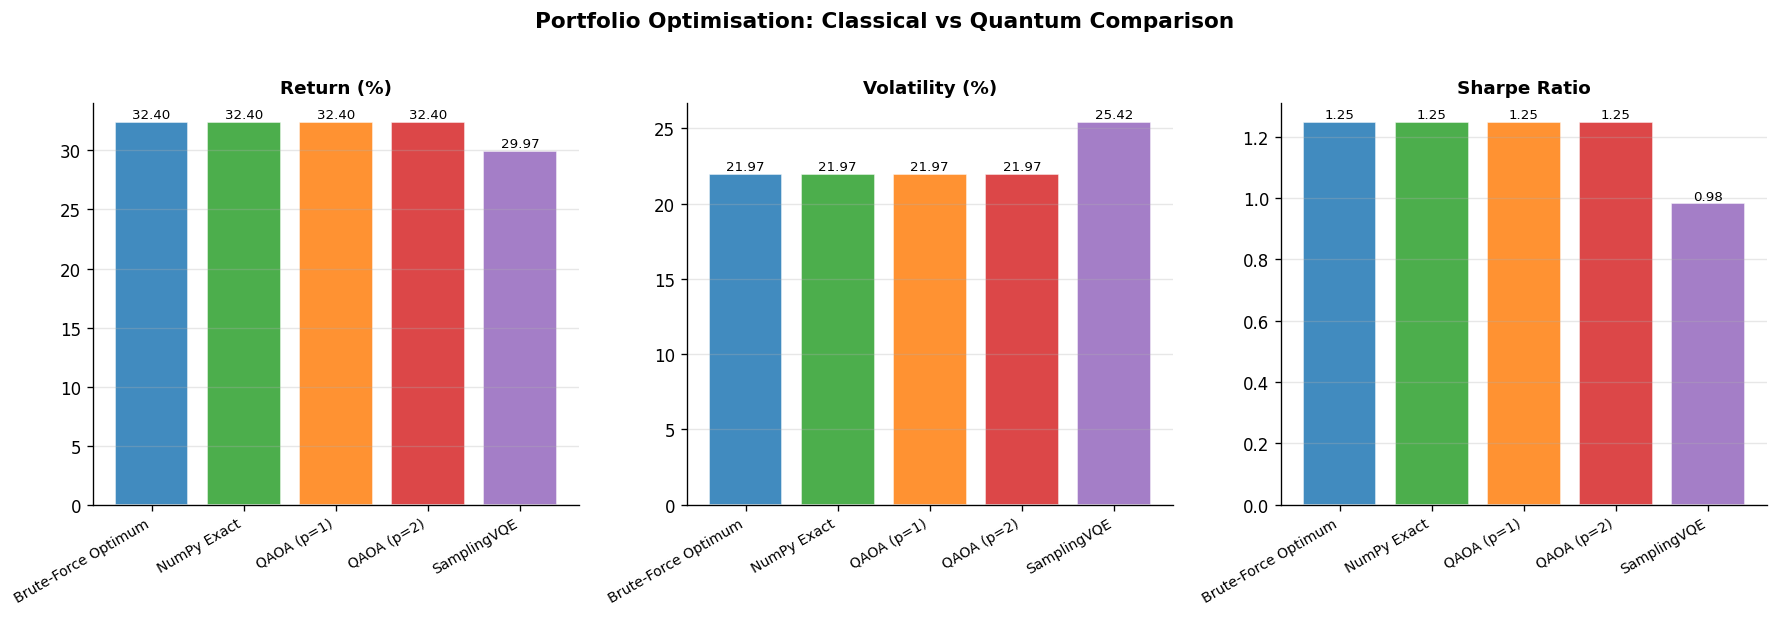

In [14]:
# ── Bar chart comparison ──────────────────────────────────────────────────
methods_list = list(results_df.index)
colors_bar   = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_plot = ["Return (%)", "Volatility (%)", "Sharpe Ratio"]
for ax, metric in zip(axes, metrics_plot):
    vals = results_df[metric].values.astype(float)
    bars = ax.bar(range(len(methods_list)), vals,
                  color=colors_bar[:len(methods_list)], alpha=0.85, edgecolor="white")
    ax.set_xticks(range(len(methods_list)))
    ax.set_xticklabels(methods_list, rotation=30, ha="right", fontsize=8.5)
    ax.set_title(metric, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002*abs(v),
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Portfolio Optimisation: Classical vs Quantum Comparison",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


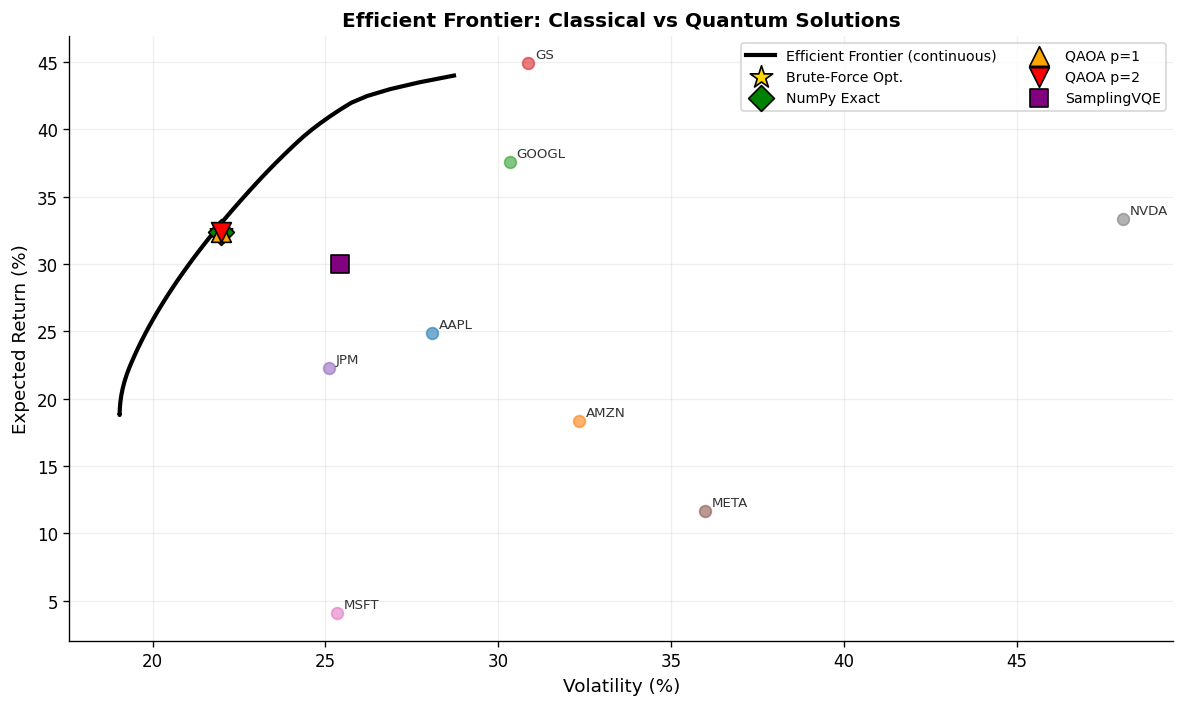

In [15]:
# ── Efficient frontier with all solutions overlaid ────────────────────────
from scipy.optimize import minimize as sp_minimize

# Classical efficient frontier sweep
R_min = mu_ann.min() * 1.01
R_max = mu_ann.max() * 0.98
R_sweep = np.linspace(R_min, R_max, 80)
ef_vols, ef_rets = [], []

for R in R_sweep:
    w0 = np.ones(N_ASSETS)/N_ASSETS
    res = sp_minimize(
        fun=lambda w: w @ cov_ann @ w,
        x0=w0, method="SLSQP",
        bounds=[(0,1)]*N_ASSETS,
        constraints=[{"type":"eq","fun":lambda w: sum(w)-1},
                     {"type":"ineq","fun":lambda w: mu_ann@w-R}],
        options={"ftol":1e-12,"maxiter":1000},
    )
    if res.success:
        ef_vols.append(np.sqrt(res.fun)*100)
        ef_rets.append((mu_ann@res.x)*100)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ef_vols, ef_rets, "k-", lw=2.5, label="Efficient Frontier (continuous)", zorder=2)

marker_specs = [("*", 200, "gold", "Brute-Force Opt."),
                ("D", 120, "green", "NumPy Exact"),
                ("^", 140, "orange", "QAOA p=1"),
                ("v", 140, "red", "QAOA p=2"),
                ("s", 120, "purple", "SamplingVQE")]

for (meth, idx), (marker, sz, color, label) in zip(methods.items(), marker_specs):
    w = np.zeros(N_ASSETS); w[list(idx)] = 1.0/BUDGET
    r_p = (mu_ann@w)*100; v_p = np.sqrt(w@cov_ann@w)*100
    ax.scatter(v_p, r_p, marker=marker, s=sz, color=color,
               edgecolors="k", zorder=5, label=label)

# Individual assets
for i, t in enumerate(TICKERS):
    ax.scatter(std_ann[i]*100, mu_ann[i]*100, s=50, alpha=0.6, zorder=3)
    ax.annotate(t, (std_ann[i]*100, mu_ann[i]*100), xytext=(4,3),
                textcoords="offset points", fontsize=8, alpha=0.8)

ax.set_xlabel("Volatility (%)", fontsize=11)
ax.set_ylabel("Expected Return (%)", fontsize=11)
ax.set_title("Efficient Frontier: Classical vs Quantum Solutions", fontsize=12, fontweight="bold")
ax.legend(fontsize=8.5, ncol=2); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()


---
## Section 10 · NISQ Limitations and Discussion

### 10.1 Current Hardware Limitations

| Limitation | Description | Impact on Portfolio Opt. |
|---|---|---|
| Qubit count | 50–1000 qubits on current hardware | Limits to $n < 50$ assets |
| Gate fidelity | $\sim99.5\%$ per 2-qubit gate | Errors accumulate with circuit depth |
| Decoherence | $T_1, T_2 \sim 100\mu s$ | Limits circuit depth |
| Connectivity | Limited qubit coupling maps | Extra SWAP gates needed |
| Shot noise | Finite sampling ($\sim1000$-$10000$ shots) | Statistical noise in expectation values |

### 10.2 Why QAOA Struggles at $p=1$

For $p=1$, QAOA can only explore correlations between adjacent qubits. The optimal solution may require:
- Long-range correlations (distant assets)
- Many layers $p$ to capture full landscape

Workaround: **Warm-start QAOA** — initialise $(\gamma, \beta)$ from a classical relaxation solution.

### 10.3 Approximation Quality

The theoretical guarantee for QAOA:
- $p=1$: approximation ratio $r \geq 0.6924$ for Max-Cut (NP-hard benchmark)
- $p \to \infty$: $r \to 1$ (exact solution)
- Portfolio QUBO: similar guarantees apply asymptotically

### 10.4 The Path to Production Advantage

1. **Near-term (2025–2027)**: Hybrid classical-quantum heuristics on NISQ hardware; advantage for $n > 100$ with enough qubits.
2. **Mid-term (2027–2030)**: Error-corrected systems; QAOA replaces branch-and-bound for $n \sim 500$.
3. **Long-term (2030+)**: Fault-tolerant quantum computers; full QUBO advantage for $n > 1000$.


In [16]:
# ── QAOA convergence with number of layers ────────────────────────────────
print("Studying QAOA approximation quality vs number of layers p...")

p_vals    = [1, 2]    # keep small for notebook execution speed
objs_qaoa = []

for p in p_vals:
    init_pt = np.random.uniform(0, 2*np.pi, 2*p)
    q_p = QAOA(sampler=sampler, optimizer=COBYLA(maxiter=200),
               reps=p, initial_point=init_pt)
    res_p = MinimumEigenOptimizer(q_p).solve(qubo)
    objs_qaoa.append(res_p.fval)
    print(f"  p={p}: QUBO obj = {res_p.fval:.6f}")

print(f"  Exact (brute-force): {best_bf_obj:.6f}")

approx_ratios = [best_bf_obj / o if o != 0 else 0 for o in objs_qaoa]
print("\nApproximation ratios (exact_obj / QAOA_obj):")
for p, r in zip(p_vals, approx_ratios):
    print(f"  p={p}: {r:.4f}")
print("  (ratio >= 1 means QAOA found a solution as good or better)")


Studying QAOA approximation quality vs number of layers p...
  p=1: QUBO obj = -0.262026
  p=2: QUBO obj = -0.262026
  Exact (brute-force): -0.262026

Approximation ratios (exact_obj / QAOA_obj):
  p=1: 1.0000
  p=2: 1.0000
  (ratio >= 1 means QAOA found a solution as good or better)


In [17]:
# ── Shot noise sensitivity ────────────────────────────────────────────────
print("\nStudying sensitivity to number of shots...")
shot_sizes = [256, 512, 1024, 2048, 4096]
shot_results = []

for shots in shot_sizes:
    samp_s = AerSampler()
    samp_s.set_options(shots=shots)
    q_s = QAOA(sampler=samp_s, optimizer=COBYLA(maxiter=100), reps=1)
    res_s = MinimumEigenOptimizer(q_s).solve(qubo)
    x_s   = res_s.x.astype(int)[:N_ASSETS]
    shot_results.append({
        "shots": shots,
        "obj":   res_s.fval,
        "n_selected": sum(x_s),
        "assets": str([TICKERS[i] for i, xi in enumerate(x_s) if xi > 0.5]),
        "match_optimum": set([i for i,xi in enumerate(x_s) if xi>0.5])==set(best_bf_combo)
    })

pd.set_option("display.max_colwidth", 50)
print(pd.DataFrame(shot_results).to_string(index=False))



Studying sensitivity to number of shots...
 shots       obj  n_selected                          assets  match_optimum
   256 -0.198406           4 ['AAPL', 'GOOGL', 'GS', 'MSFT']          False
   512 -0.262026           4  ['AAPL', 'GOOGL', 'GS', 'JPM']           True
  1024 -0.262026           4  ['AAPL', 'GOOGL', 'GS', 'JPM']           True
  2048 -0.262026           4  ['AAPL', 'GOOGL', 'GS', 'JPM']           True
  4096 -0.262026           4  ['AAPL', 'GOOGL', 'GS', 'JPM']           True


---
## Section 11 · Interview Questions & Answers

**Q1. What is the cardinality-constrained portfolio optimisation problem?**
**A:** Select exactly $k$ assets from $n$ to optimise risk-adjusted return. The constraint $\sum x_i = k$ with $x_i \in \{0,1\}$ makes it NP-hard. The number of feasible solutions $\binom{n}{k}$ grows combinatorially — e.g. $\binom{50}{20} \approx 4.7 \times 10^{13}$.

**Q2. How does QAOA work and why is it relevant for portfolio optimisation?**
**A:** QAOA alternates between applying the cost Hamiltonian $e^{-i\gamma H_C}$ (encoding the objective) and the mixer $e^{-i\beta H_M}$ (enabling superposition). The variational parameters $(\gamma, \beta)$ are classically optimised. For portfolio QUBO, $H_C$ encodes risk, return, and the budget penalty — the ground state corresponds to the optimal portfolio.

**Q3. What is the difference between QAOA and VQE?**
**A:** Both are variational quantum algorithms, but:
- **QAOA** uses a structured ansatz derived from the problem Hamiltonian (alternating cost/mixer layers).
- **VQE** uses a general parameterised ansatz (e.g., `TwoLocal`) with no problem-specific structure.
- QAOA has theoretical performance guarantees; VQE is more flexible for hardware.
- `SamplingVQE` uses shot-based sampling, making it more realistic for NISQ.

**Q4. What is the QUBO matrix $Q$ and how is it constructed for portfolio optimisation?**
**A:** $Q$ is an $n \times n$ matrix where the minimisation problem is $\min \mathbf{x}^T Q \mathbf{x}$. For portfolio optimisation:
$$Q_{ij} = q\Sigma_{ij} + A\mathbb{1}_{i\neq j}, \quad Q_{ii} = q\Sigma_{ii} - (1-q)\mu_i + A(1-2k)$$
where $q$ is the risk factor and $A$ is the penalty strength.

**Q5. Why use `AerSampler` instead of real quantum hardware for this notebook?**
**A:** Real hardware has gate errors, decoherence, and limited qubit connectivity. `AerSampler` provides a noise-free simulation ideal for algorithm development and verification. For production deployment, one would run on real hardware with error mitigation techniques.

**Q6. What is the approximation ratio of QAOA and how does it improve with depth $p$?**
**A:** For $p=1$ QAOA on Max-Cut, the proven ratio is $\geq 0.6924$. For portfolio QUBO, empirical results show similar behaviour. As $p \to \infty$, QAOA converges to the exact solution (approximation ratio $\to 1$), but circuit depth grows as $O(p \cdot n)$, limiting NISQ feasibility.

**Q7. How did JPMorgan use quantum computing for portfolio optimisation?**
**A:** JPMorgan demonstrated QUBO-based portfolio selection using QAOA on IBM quantum hardware (2020) and IonQ trapped-ion computers (2022). They showed that cardinality-constrained portfolios could be approximately solved on current hardware, with results improving as qubit counts and fidelities increase. They also pioneered QAE for option pricing (Stamatopoulos et al., 2020).


---
## Section 12 · References

1. Farhi, E., Goldstone, J., & Gutmann, S. (2014). *A Quantum Approximate Optimization Algorithm*. arXiv:1411.4028.
2. Stamatopoulos, N. et al. (2020). *Option pricing using quantum computers*. Quantum, 4, 291.
3. Mugel, S. et al. (2022). *Dynamic portfolio optimization with real datasets using quantum processors*. Physical Review Research, 4(1).
4. Peruzzo, A. et al. (2014). *A variational eigenvalue solver on a photonic quantum processor*. Nature Communications, 5, 4213.
5. Orús, R., Mugel, S., & Lizaso, E. (2019). *Quantum computing for finance: Overview and prospects*. Reviews in Physics, 4, 100028.
6. Brandhofer, S. et al. (2022). *Benchmarking the performance of portfolio optimization with QAOA*. Quantum Information Processing, 22, 25.
7. Qiskit Finance: https://qiskit-community.github.io/qiskit-finance/
8. JPMorgan Chase Quantum Research: https://www.jpmorgan.com/technology/technology-blog/quantum-computing

## Section 13 · Future Improvements

1. **Warm-start QAOA**: initialise from the classical SDP relaxation for better convergence.
2. **Recursive QAOA (RQAOA)**: iteratively fix variables to reduce problem size.
3. **Noise simulation**: add realistic gate errors using `AerSimulator` noise models.
4. **Multi-objective QUBO**: add ESG, sector, and liquidity constraints.
5. **Real quantum hardware**: run on IBM Quantum via `qiskit-ibm-runtime`.
6. **Quantum portfolio with short-selling**: extend binary variables to allow $x_i \in \{-1, 0, 1\}$.
